# Exploratory Data Analysis

Comprehensive exploration of the WiDS 2023 dataset - target distribution, temporal patterns, spatial analysis, feature correlations, and data quality assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
train = pd.read_csv('../data/train_data.csv')
test = pd.read_csv('../data/test_data.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (375734, 246)
Test shape: (31354, 245)


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 375734 entries, 0 to 375733
Columns: 246 entries, index to wind-vwnd-925-2010-20
dtypes: float64(240), int64(4), str(2)
memory usage: 705.2 MB


In [4]:
train.describe()

,index,lat,lon,contest-pevpr-sfc-gauss-14d__pevpr,nmme0-tmp2m-34w__cancm30,nmme0-tmp2m-34w__cancm40,nmme0-tmp2m-34w__ccsm30,nmme0-tmp2m-34w__ccsm40,nmme0-tmp2m-34w__cfsv20,nmme0-tmp2m-34w__gfdlflora0,...,wind-vwnd-925-2010-11,wind-vwnd-925-2010-12,wind-vwnd-925-2010-13,wind-vwnd-925-2010-14,wind-vwnd-925-2010-15,wind-vwnd-925-2010-16,wind-vwnd-925-2010-17,wind-vwnd-925-2010-18,wind-vwnd-925-2010-19,wind-vwnd-925-2010-20
count,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,359800.000000,375734.000000,375734.000000,375734.000000,...,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000
mean,187866.500000,0.592766,0.517964,276.744064,10.801682,12.726739,10.099323,11.638229,10.733886,11.772646,...,-1.209959,-8.109918,6.800684,19.251970,-17.697565,-9.846867,-6.231860,16.014364,10.489945,11.296334
std,108465.207359,0.251744,0.272059,198.085182,10.952417,11.073553,10.339626,10.574276,9.403434,10.689967,...,37.317333,36.201507,38.458878,25.288526,31.946748,34.164678,27.050356,25.847455,25.070435,25.113214
min,0.000000,0.000000,0.000000,-2.310000,-14.960000,-14.970000,-11.720000,-17.560000,-13.720000,-13.330000,...,-94.570000,-89.940000,-64.870000,-39.280000,-100.560000,-106.080000,-93.980000,-52.610000,-66.110000,-57.610000
25%,93933.250000,0.409091,0.300000,104.062500,1.550000,3.650000,1.640000,3.080000,3.390000,2.970000,...,-27.200000,-33.350000,-19.650000,1.960000,-40.030000,-32.170000,-20.170000,-0.360000,-6.790000,-5.570000
50%,187866.500000,0.590909,0.533333,250.320000,9.950000,11.890000,9.490000,11.600000,10.890000,11.280000,...,-3.200000,-9.390000,2.330000,20.050000,-16.710000,-8.560000,-6.030000,18.650000,11.860000,11.650000
75%,281799.750000,0.818182,0.766667,420.010000,20.230000,22.110000,18.740000,20.360000,18.330000,20.300000,...,24.940000,17.960000,28.660000,35.090000,4.390000,10.500000,11.630000,31.210000,29.040000,29.180000
max,375733.000000,1.000000,1.000000,1185.140000,36.080000,36.030000,33.390000,34.640000,35.750000,38.350000,...,113.920000,96.550000,106.420000,91.760000,56.550000,83.890000,64.850000,90.390000,76.890000,88.660000


## Target Variable Analysis

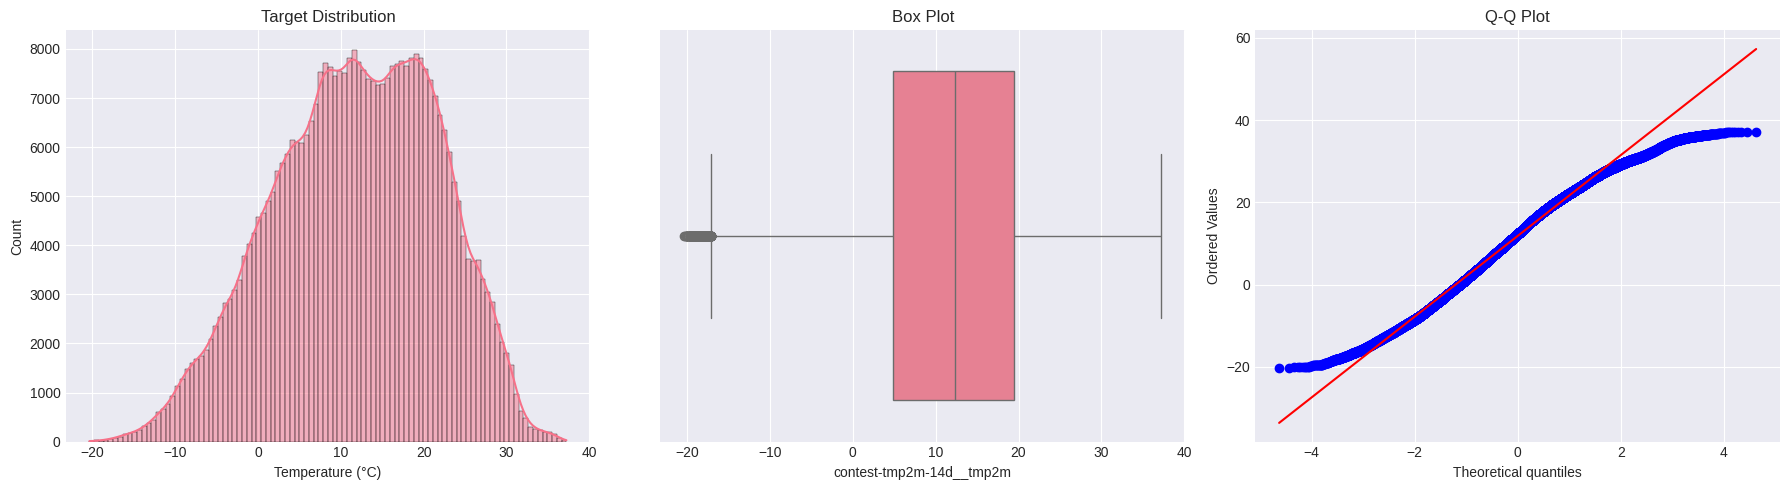

In [5]:
target_col = 'contest-tmp2m-14d__tmp2m'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(train[target_col], bins=100, kde=True, ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Temperature (°C)')

sns.boxplot(x=train[target_col], ax=axes[1])
axes[1].set_title('Box Plot')

from scipy import stats
stats.probplot(train[target_col], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('../outputs/plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Temporal Patterns

/tmp/ipykernel_26486/2571331945.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['startdate_dt'] = pd.to_datetime(train['startdate'], format='mixed')
/tmp/ipykernel_26486/2571331945.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['month'] = train['startdate_dt'].dt.month
/tmp/ipykernel_26486/2571331945.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

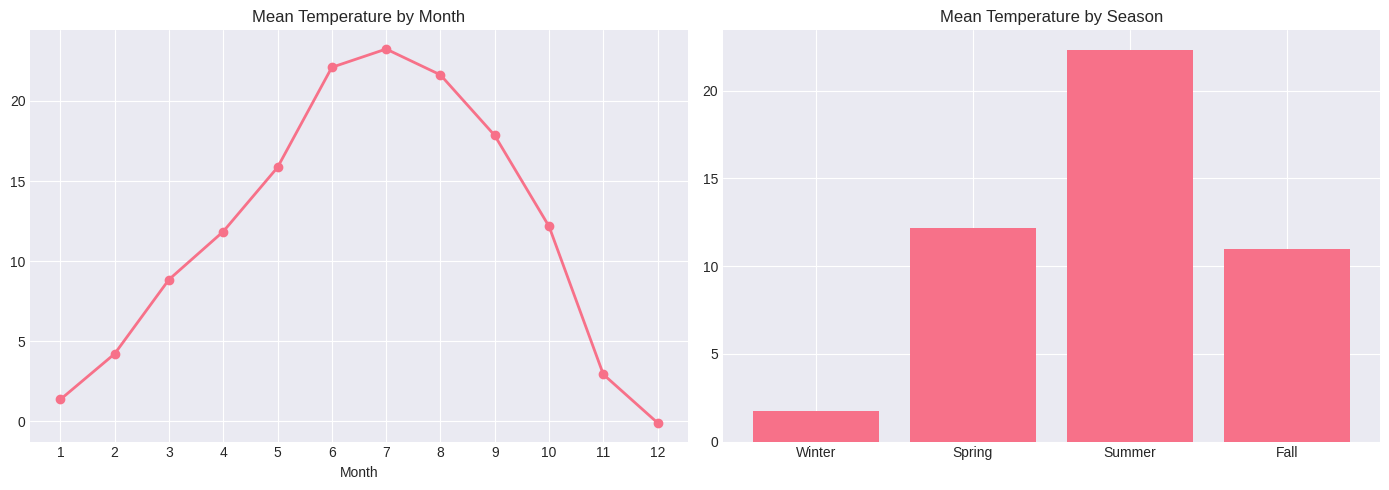

In [6]:
train['startdate_dt'] = pd.to_datetime(train['startdate'], format='mixed')
train['month'] = train['startdate_dt'].dt.month
train['season'] = train['month'].map({12:0, 1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3})
season_labels = {0: 'Winter', 1: 'Spring', 2: 'Summer', 3: 'Fall'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_means = train.groupby('month')[target_col].mean()
axes[0].plot(monthly_means.index, monthly_means.values, marker='o', linewidth=2)
axes[0].set_xticks(range(1, 13))
axes[0].set_title('Mean Temperature by Month')
axes[0].set_xlabel('Month')

seasonal_means = train.groupby('season')[target_col].mean()
axes[1].bar([season_labels[s] for s in seasonal_means.index], seasonal_means.values)
axes[1].set_title('Mean Temperature by Season')

plt.tight_layout()
plt.show()

## Spatial Analysis

Unique locations: 514


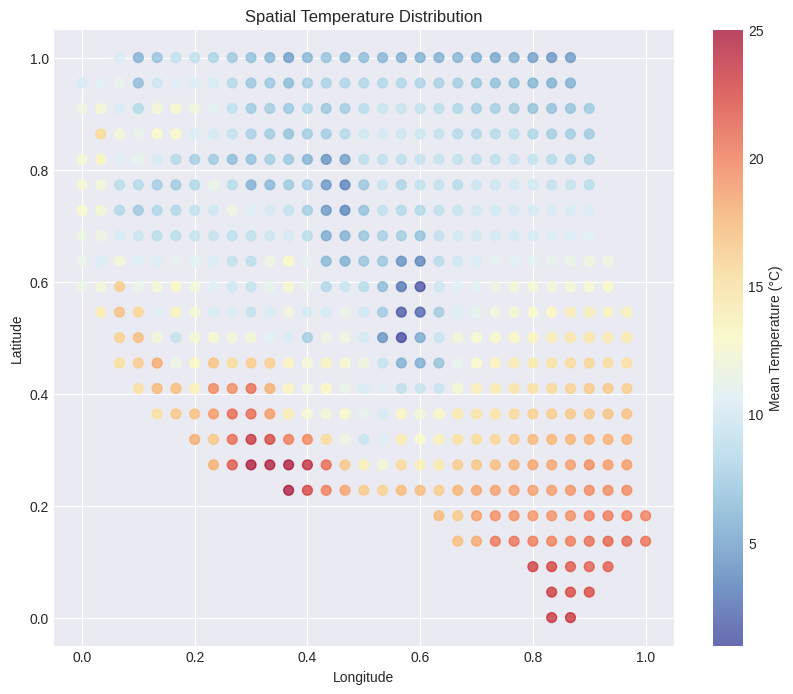

In [7]:
print(f"Unique locations: {train[['lat', 'lon']].drop_duplicates().shape[0]}")
fig, ax = plt.subplots(figsize=(10, 8))
location_means = train.groupby(['lat', 'lon'])[target_col].mean().reset_index()
scatter = ax.scatter(location_means['lon'], location_means['lat'],
                     c=location_means[target_col], cmap='RdYlBu_r', s=50, alpha=0.7)
plt.colorbar(scatter, label='Mean Temperature (°C)')
ax.set_title('Spatial Temperature Distribution')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.savefig('../outputs/plots/spatial_temperature_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Climate Region Analysis

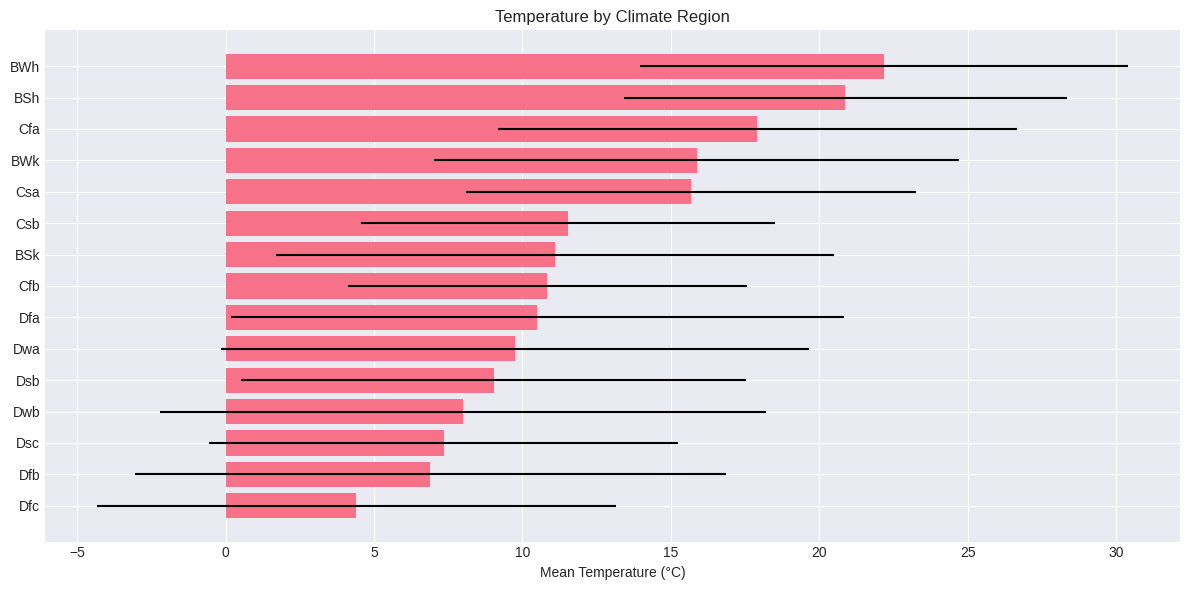

In [8]:
region_col = 'climateregions__climateregion'
fig, ax = plt.subplots(figsize=(12, 6))
region_means = train.groupby(region_col)[target_col].agg(['mean', 'std']).sort_values('mean')
ax.barh(region_means.index, region_means['mean'], xerr=region_means['std'])
ax.set_title('Temperature by Climate Region')
ax.set_xlabel('Mean Temperature (°C)')
plt.tight_layout()
plt.show()

## NMME Forecast Model Comparison

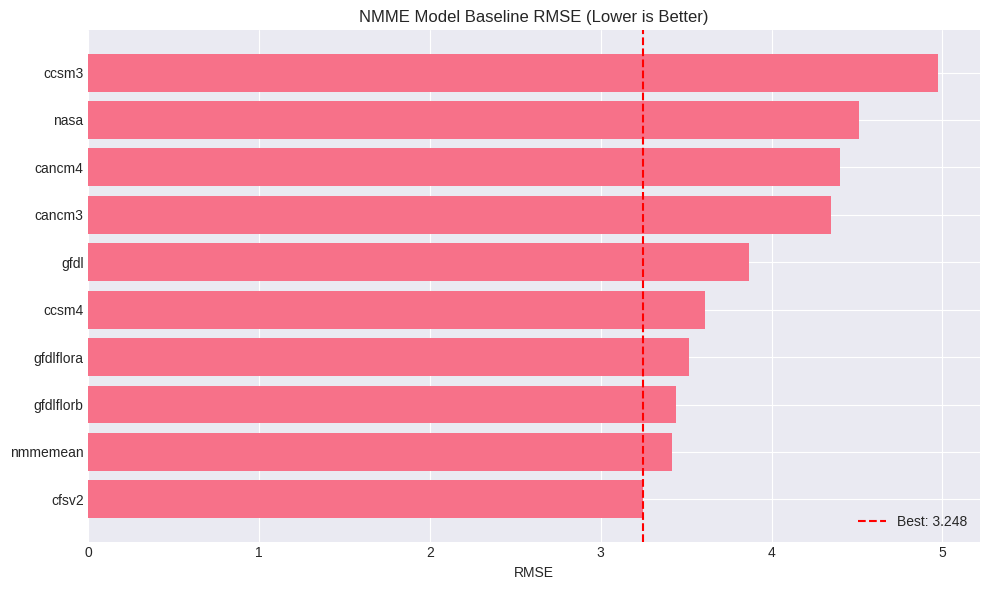

In [9]:
nmme_cols = [c for c in train.columns if c.startswith('nmme-tmp2m-34w__')]
nmme_rmse = {}
for col in nmme_cols:
    rmse = np.sqrt(((train[target_col] - train[col]) ** 2).mean())
    nmme_rmse[col.split('__')[-1]] = rmse

fig, ax = plt.subplots(figsize=(10, 6))
models_sorted = dict(sorted(nmme_rmse.items(), key=lambda x: x[1]))
ax.barh(list(models_sorted.keys()), list(models_sorted.values()))
ax.set_title('NMME Model Baseline RMSE (Lower is Better)')
ax.set_xlabel('RMSE')
ax.axvline(x=min(nmme_rmse.values()), color='red', linestyle='--', label=f'Best: {min(nmme_rmse.values()):.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## Correlation Analysis

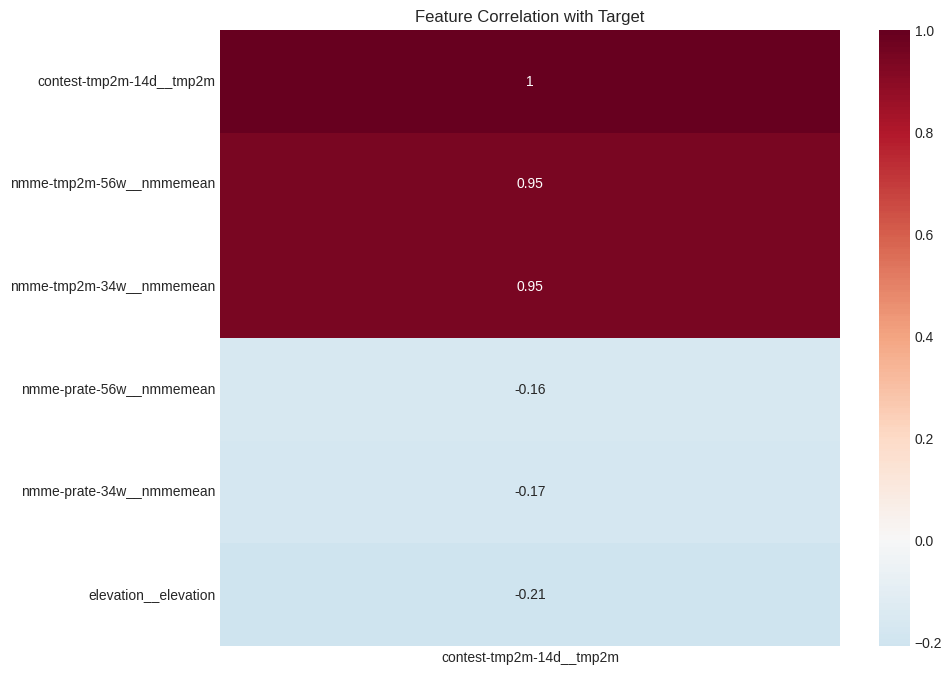

In [10]:
nmme_mean_cols = [c for c in train.columns if 'nmmemean' in c or 'nmea' in c]
key_features = ['elevation__elevation'] + nmme_mean_cols
corr_cols = [c for c in key_features if c in train.columns]
corr = train[corr_cols + [target_col]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr[[target_col]].sort_values(target_col, ascending=False),
            annot=True, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation with Target')
plt.savefig('../outputs/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Missing Values Analysis

In [11]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Features with missing values: {len(missing)}")
if len(missing) > 0:
    print(missing.head(20))
else:
    print("No missing values found!")

Features with missing values: 8
nmme0-tmp2m-34w__ccsm30    15934
nmme0-prate-56w__ccsm30    15934
ccsm30                     15934
nmme0-prate-34w__ccsm30    15934
nmme-prate-56w__ccsm3      10280
nmme-tmp2m-56w__ccsm3      10280
nmme-prate-34w__ccsm3       8738
nmme-tmp2m-34w__ccsm3       8738
dtype: int64


## Feature Group Summary

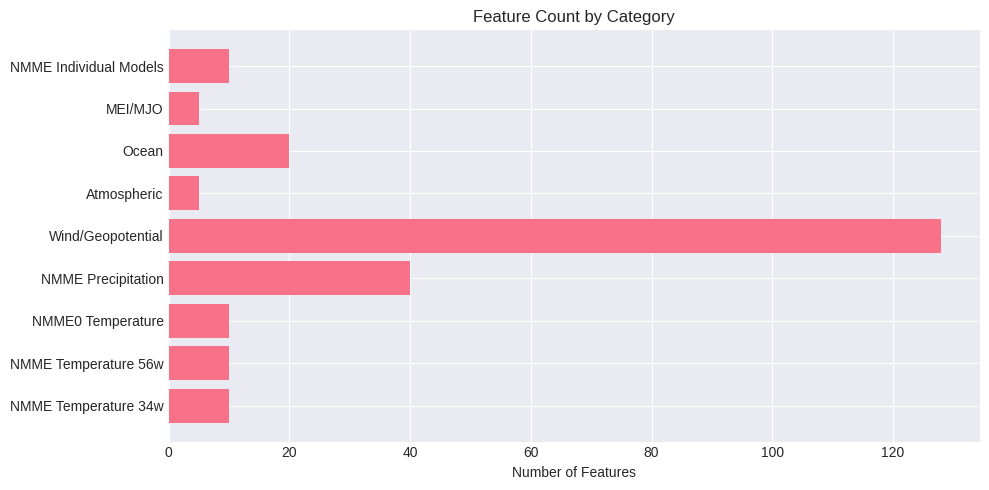

Total features: 245


In [12]:
feature_groups = {
    'NMME Temperature 34w': len([c for c in train.columns if 'nmme-tmp2m-34w' in c]),
    'NMME Temperature 56w': len([c for c in train.columns if 'nmme-tmp2m-56w' in c]),
    'NMME0 Temperature': len([c for c in train.columns if 'nmme0-tmp2m' in c]),
    'NMME Precipitation': len([c for c in train.columns if 'nmme-prate' in c or 'nmme0-prate' in c]),
    'Wind/Geopotential': len([c for c in train.columns if 'wind' in c]),
    'Atmospheric': len([c for c in train.columns if any(x in c for x in ['rhum', 'pres', 'prwtr', 'slp', 'pevpr'])]),
    'Ocean': len([c for c in train.columns if c in ['sst', 'icec'] or c.startswith('sst-') or c.startswith('icec-')]),
    'MEI/MJO': len([c for c in train.columns if c.startswith('mei') or c.startswith('mjo')]),
    'NMME Individual Models': len([c for c in train.columns if c in ['cancm30','cancm40','ccsm30','ccsm40','cfsv20','gfdlflora0','gfdlflorb0','gfdl0','nasa0','nmme0mean']]),
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(feature_groups.keys()), list(feature_groups.values()))
ax.set_title('Feature Count by Category')
ax.set_xlabel('Number of Features')
plt.tight_layout()
plt.show()

print(f"Total features: {train.shape[1] - 4}")